 **E-commerce Sales Data Visualization**

This project uses visualizations to understand sales performance, customer behavior, and operational patterns.

In [ ]:
#Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Load Dataset
df= pd.read_csv("ecommerce_sales_analytics_5000.csv")

In [ ]:
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   object 
 4   region            5000 non-null   object 
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   object 
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


In [ ]:
df["order_date"]=pd.to_datetime(df["order_date"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          5000 non-null   int64         
 1   order_date        5000 non-null   datetime64[ns]
 2   customer_id       5000 non-null   int64         
 3   product_category  5000 non-null   object        
 4   region            5000 non-null   object        
 5   quantity          5000 non-null   int64         
 6   unit_price        5000 non-null   float64       
 7   discount          5000 non-null   float64       
 8   payment_method    5000 non-null   object        
 9   delivery_days     5000 non-null   int64         
 10  customer_rating   5000 non-null   float64       
 11  revenue           5000 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(4), object(3)
memory usage: 468.9+ KB


**Visualization**

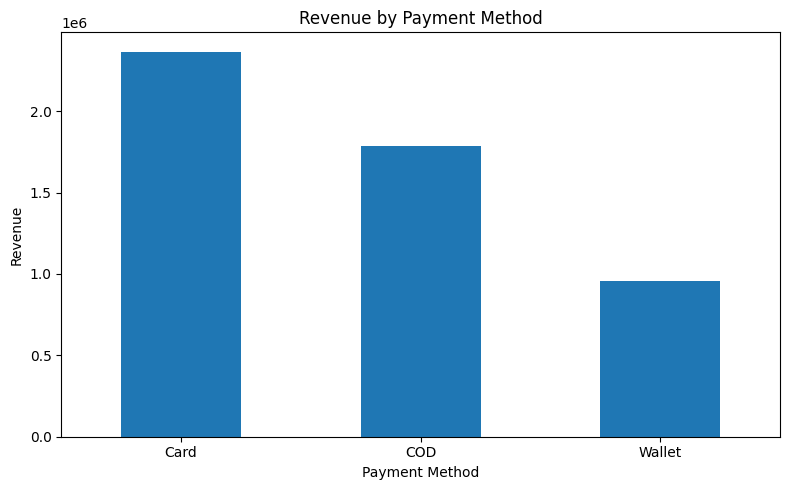

In [ ]:
payment_revenue=df.groupby("payment_method")["revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
payment_revenue.plot(kind="bar")
plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

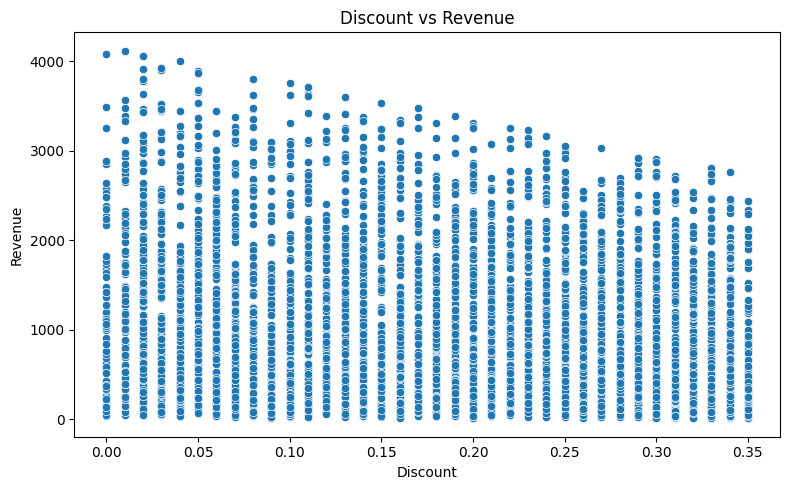

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="discount", y="revenue")
plt.title("Discount vs Revenue")
plt.xlabel("Discount")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

The scatter plot shows how revenue varies across different discount levels.

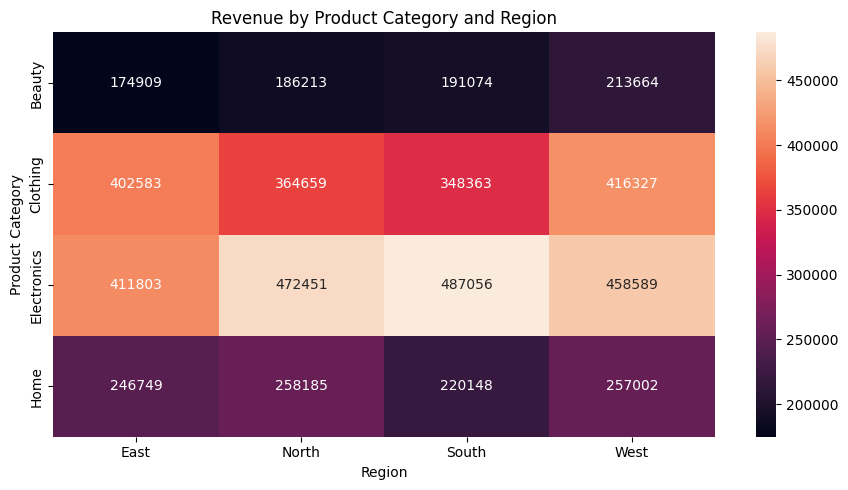

In [ ]:
category_region=pd.pivot_table(df, values="revenue", index="product_category", columns="region", aggfunc="sum")

plt.figure(figsize=(9,5))
sns.heatmap(category_region, annot=True, fmt=".0f")
plt.title("Revenue by Product Category and Region")
plt.xlabel("Region")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()


The heatmap makes it easier to compare revenue across product categories and regions at the same time.

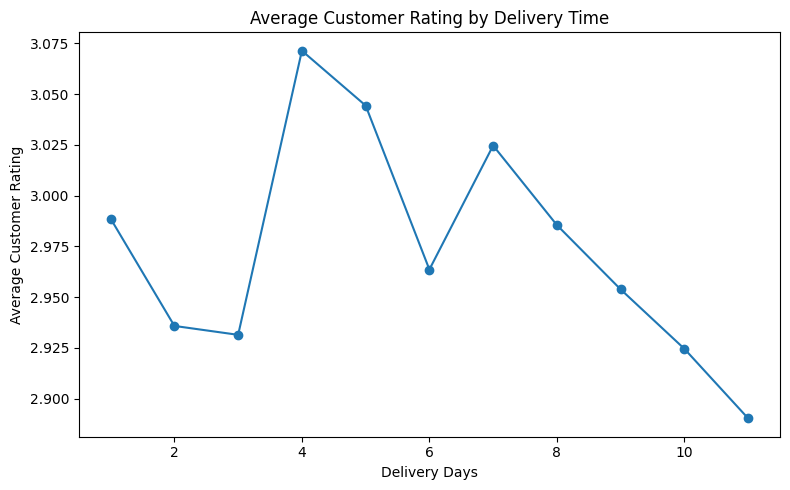

In [ ]:
delivery_rating = df.groupby("delivery_days")["customer_rating"].mean()

plt.figure(figsize=(8, 5))
plt.plot(delivery_rating.index, delivery_rating.values, marker='o')
plt.title("Average Customer Rating by Delivery Time")
plt.xlabel("Delivery Days")
plt.ylabel("Average Customer Rating")
plt.tight_layout()
plt.show()

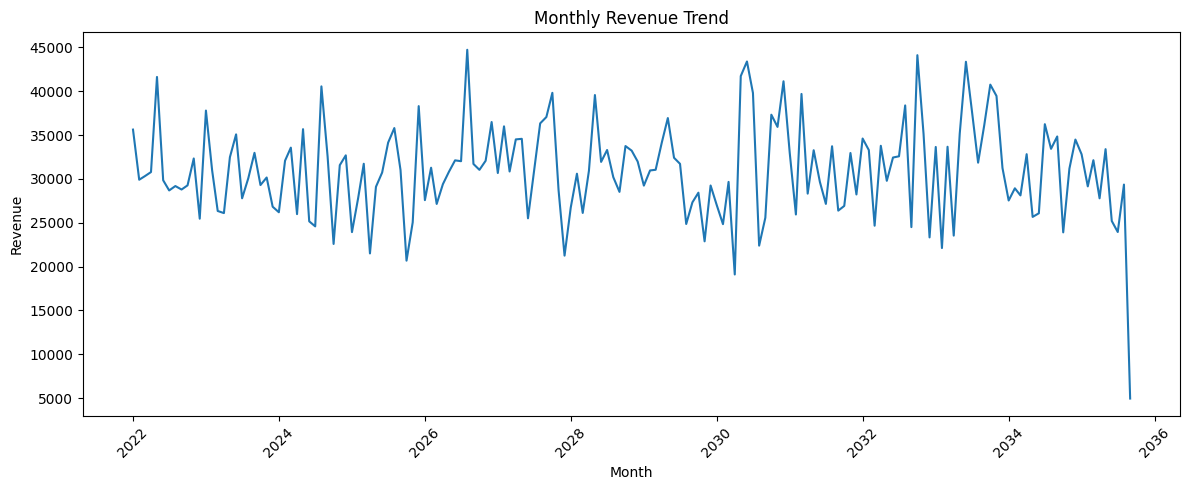

In [ ]:
monthly_revenue=df.groupby(df["order_date"].dt.to_period("M"))["revenue"].sum()

monthly_revenue.index=monthly_revenue.index.to_timestamp()

plt.figure(figsize=(12,5))
plt.plot(monthly_revenue.index, monthly_revenue.values)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Monthly revenue changes over time, showing variations in sales performance across different periods.